# Разведочный анализ данных

**Целевые переменные:**

- *IC50* — концентрация полумаксимального ингибирования. Характеризует противовирусную активность: чем ниже, тем более эффективно вещество подавляет вирус.
- *CC50* — концентрация полумаксимальной цитотоксичности. Характеризует токсичность для клеток: чем выше, тем безопаснее вещество.
- *SI* — индекс селективности, `SI = CC50 / IC50`. Показывает терапевтическое окно: во сколько раз эффективная концентрация ниже токсичной. Препарат-кандидат должен иметь `SI > 1`, а практически значимыми считаются значения `SI > 8`.

## 1. Импорт библиотек

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 2. Загрузка данных

In [2]:
raw_data = pd.read_excel("../data/dataset.xlsx")

raw_data.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


По постановке задачи целевые переменные — `IC50, mM`, `CC50, mM` и `SI`. На них будем строить модели регрессии и классификации.

Первая колонка — технический индекс, уберём. Также удалим полностью одинаковые строки. Наблюдения с одинаковыми дескрипторами, но различающимися целевыми значениями, на этом этапе сохраняем.

In [3]:
TARGET_COLUMNS = ["IC50, mM", "CC50, mM", "SI"]

data = raw_data.iloc[:, 1:].copy()
data = data.drop_duplicates()

print(f"Размер таблицы для анализа: {data.shape[0]} строк, {data.shape[1]} колонок")
print(f"Целевые колонки: {TARGET_COLUMNS}")

Размер таблицы для анализа: 969 строк, 213 колонок
Целевые колонки: ['IC50, mM', 'CC50, mM', 'SI']


## 3. Первичный осмотр таблицы

In [4]:
feature_columns = [col for col in data.columns if col not in TARGET_COLUMNS]

print(f"Признаков: {len(feature_columns)}, целевых: {len(TARGET_COLUMNS)}")

data.info()

Признаков: 210, целевых: 3
<class 'pandas.DataFrame'>
Index: 969 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


In [13]:
repeated_mask = data.duplicated(
    subset=feature_columns,
    keep=False,
)

unique_descriptor_count = (
    data[feature_columns]
    .drop_duplicates()
    .shape[0]
)

repeated_group_count = (
    data.loc[repeated_mask, feature_columns]
    .drop_duplicates()
    .shape[0]
)

print(f"Уникальных наборов дескрипторов: {unique_descriptor_count}")
print(f"Строк в повторяющихся группах: {repeated_mask.sum()}")
print(f"Повторяющихся групп дескрипторов: {repeated_group_count}")

Уникальных наборов дескрипторов: 804
Строк в повторяющихся группах: 253
Повторяющихся групп дескрипторов: 88


После удаления полностью одинаковых строк в данных остались наблюдения с одинаковыми молекулярными дескрипторами, но различающимися значениями целевых переменных. Это не полные дубли. Такие строки могут соответствовать повторным измерениям одной структуры или разным объектам с одинаковым набором рассчитанных дескрипторов.

Удалять такие наблюдения не будем, поскольку они содержат разные значения целевых переменных. При построении моделей объекты с одинаковыми дескрипторами объединим в группы. Объекты из одной группы не смогут одновременно попасть в обучающую и тестовую выборки. Такой подход снижает риск утечки данных и завышения качества моделей.

Все колонки числовые — это готовые молекулярные дескрипторы. Кодирование не требуется.

## 4. Пропуски и дубликаты

In [5]:
missing_by_column = data.isna().sum().sort_values(ascending=False)

print(f"Всего пропущенных значений: {int(data.isna().sum().sum())}")
print(f"Колонок с пропусками: {(missing_by_column > 0).sum()}")

missing_table = pd.DataFrame(
    {
        "missing_count": missing_by_column,
        "missing_share": missing_by_column / len(data),
    }
)
display(missing_table.head(15))

Всего пропущенных значений: 36
Колонок с пропусками: 12


,missing_count,missing_share
MinAbsPartialCharge,3,0.003096
MaxPartialCharge,3,0.003096
MinPartialCharge,3,0.003096
MaxAbsPartialCharge,3,0.003096
BCUT2D_MWHI,3,0.003096
BCUT2D_MRLOW,3,0.003096
BCUT2D_MRHI,3,0.003096
BCUT2D_LOGPLOW,3,0.003096
BCUT2D_LOGPHI,3,0.003096
BCUT2D_CHGLO,3,0.003096


Пропусков немного, не более 3 на колонку. Заполним медианой, так как она устойчива к выбросам и скошенным распределениям.

## 5. Анализ целевых переменных

Смотрим, как распределены IC50, CC50 и SI: разброс, асимметрию, есть ли нули. От этого зависит, нужно ли преобразование перед регрессией.

In [6]:
target_stats = data[TARGET_COLUMNS].describe().T

target_stats["median"] = data[TARGET_COLUMNS].median()
target_stats["skew"] = data[TARGET_COLUMNS].skew()
target_stats["zero_or_negative"] = (data[TARGET_COLUMNS] <= 0).sum()

display(target_stats.round(4))

,count,mean,std,min,25%,50%,75%,max,median,skew,zero_or_negative
"IC50, mM",969.0,220.7262,397.1724,0.0035,12.5154,45.3384,231.3731,4128.5294,45.3384,3.7580,0
"CC50, mM",969.0,586.4199,633.6245,0.7008,99.9993,424.1662,891.7769,4538.9762,424.1662,1.9967,0
SI,969.0,73.9679,695.5647,0.0115,1.4881,3.9000,16.3750,15620.6000,3.9000,17.7282,0


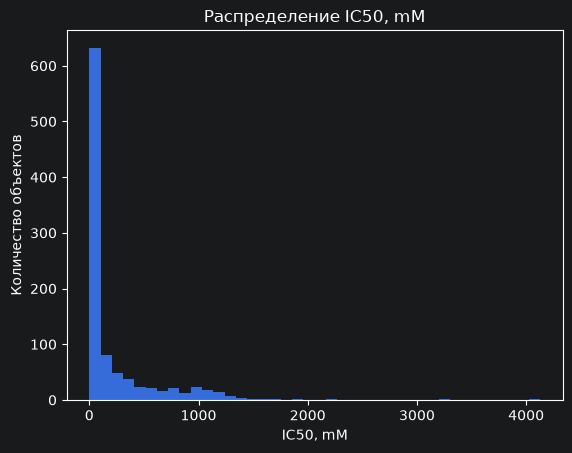

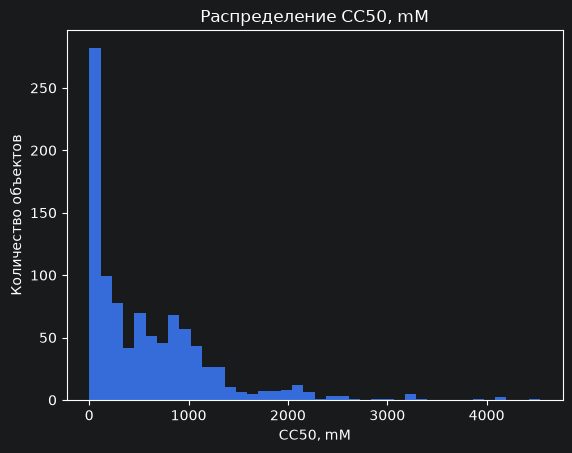

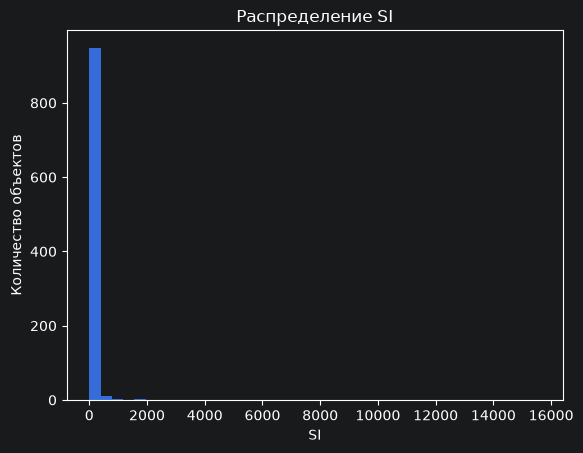

In [7]:
for target in TARGET_COLUMNS:
    plt.figure()
    plt.hist(data[target].dropna(), bins=40)
    plt.title(f"Распределение {target}")
    plt.xlabel(target)
    plt.ylabel("Количество объектов")
    plt.show()

Распределения несимметричны: основная масса значений сосредоточена слева (медиана намного меньше среднего), а небольшое число очень больших значений растягивает хвост вправо. Для IC50 и CC50 это ожидаемо — концентрации полумаксимального эффекта могут различаться на порядки в зависимости от вещества.

Такая асимметрия мешает регрессии. Большинство моделей штрафуют абсолютную разницу между предсказанием и фактом, и несколько экстремально больших значений на правом хвосте получат непропорционально большой вес в функции потерь. Модель будет стараться угадать именно их, жертвуя качеством на основной массе объектов.

Один из способов справиться с этим — преобразовать целевую переменную так, чтобы сжать длинный хвост. Для положительных величин, меняющихся на порядки, стандартный приём — логарифмирование. Оно переводит абсолютные различия в относительные: ошибка в 2 раза становится одинаково дорогой и на малых, и на больших значениях.

Берём log1p — это `log(x + 1)`. Для больших "x" прибавление единицы почти ничего не меняет, и log1p ведёт себя как обычный логарифм. Но когда "x" близко к нулю, единица спасает: log(0) не определён, а `log1p(0) = 0`. Для наших данных это важно — минимальное значение SI составляет 0.01, и обычный логарифм дал бы значения, уходящие в большой минус.

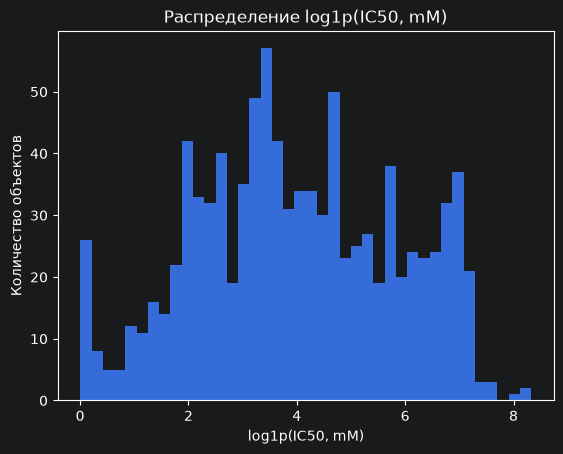

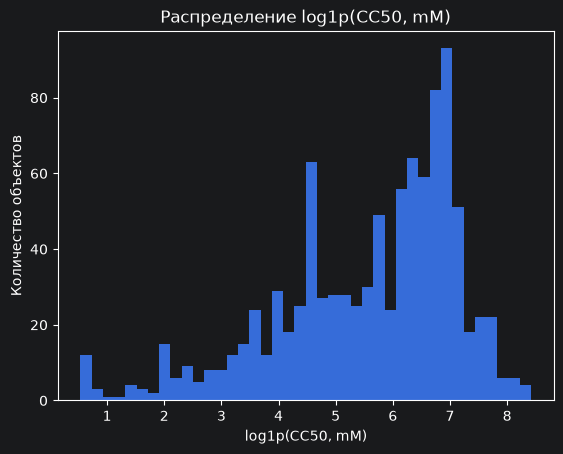

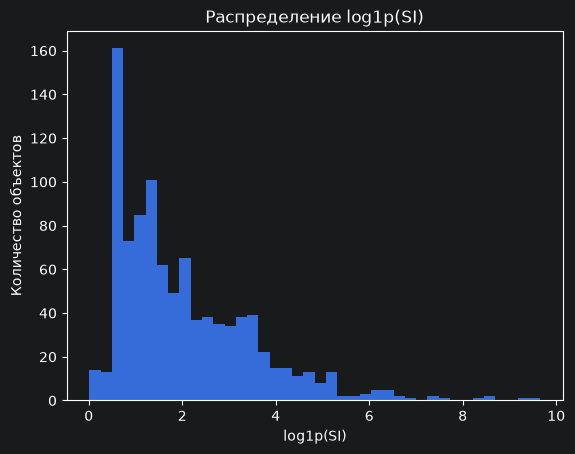

In [8]:
for target in TARGET_COLUMNS:
    plt.figure()
    plt.hist(np.log1p(data[target].dropna()), bins=40)
    plt.title(f"Распределение log1p({target})")
    plt.xlabel(f"log1p({target})")
    plt.ylabel("Количество объектов")
    plt.show()

## 6. Выбросы в целевых переменных

Правый хвост у всех трёх переменных тянется далеко за основную массу значений. Самый простой способ отделить "норму" от хвоста — метод межквартильного размаха (IQR): всё, что дальше чем `1.5 × (Q3 − Q1)` от квартилей, считается выбросом. По этому критерию выбросов немало: 14% для IC50, 4% для CC50 и 12% для SI.

Если их убрать и обучить регрессию, метрики улучшатся — для SI, например, MAE падает в 19 раз. Но это не улучшение модели, а упрощение задачи: мы убираем из теста самые трудные примеры и замеряем качество на "удобной" части выборки. Для IC50 и CC50 — то же самое: выбросы по IQR уходят далеко вверх, в область высоких концентраций, и именно на них модель ошибается сильнее всего.

В химических данных такие значения — не ошибка измерения, а реальные вещества. SI = CC50 / IC50, и высокий SI означает, что вещество убивает вирус при концентрации сильно ниже токсичной. Это ровно то, что мы ищем. Выкинуть верхний хвост SI — потерять самые перспективные кандидаты в лекарства. Выкинуть хвост IC50 и CC50 — потерять информацию о том, какие молекулы, наоборот, слишком токсичны или неэффективны.

Поэтому выбросы не трогаем.

## 7. Баланс классов

Для задач классификации важно соотношение классов. Если одного класса сильно больше, модель может выучить всегда предсказывать большинство и получить высокую долю правильных ответов, не решив задачу по существу. Проверим баланс для всех четырёх классификационных задач.

In [9]:
classification_targets = []

for target in TARGET_COLUMNS:
    threshold = data[target].median()
    labels = (data[target] > threshold).astype(int)
    counts = labels.value_counts().sort_index()

    classification_targets.append(
        {
            "task": f"{target} > median",
            "threshold": threshold,
            "class_0_count": counts.iloc[0],
            "class_1_count": counts.iloc[1],
            "class_1_share": labels.mean(),
        }
    )

si_8_labels = (data["SI"] > 8).astype(int)
si_8_counts = si_8_labels.value_counts().sort_index()
classification_targets.append(
    {
        "task": "SI > 8",
        "threshold": 8,
        "class_0_count": si_8_counts.iloc[0],
        "class_1_count": si_8_counts.iloc[1],
        "class_1_share": si_8_labels.mean(),
    }
)

class_balance = pd.DataFrame(classification_targets)
display(class_balance.round(4))

,task,threshold,class_0_count,class_1_count,class_1_share
0,"IC50, mM > median",45.3384,485,484,0.4995
1,"CC50, mM > median",424.1662,485,484,0.4995
2,SI > median,3.9000,485,484,0.4995
3,SI > 8,8.0000,626,343,0.3540


Три задачи с разбиением по медиане практически сбалансированы — деление примерно 50/50, можно спокойно использовать accuracy как одну из метрик.

В `SI > 8` положительных примеров всего 36%. Если модель просто скажет "все молекулы имеют `SI <= 8`", она получит 64% правильных ответов, ничего не предсказывая. Поэтому для этой задачи accuracy одной недостаточно — добавим F1-score и ROC-AUC, которые чувствительны к дисбалансу.

## 8. Константные и почти константные признаки

Признак, который принимает одно и то же значение для всех объектов, бесполезен — по нему невозможно ничего предсказать. То же самое с признаками, у которых почти все значения одинаковы: даже если несколько объектов отличаются, информативность околонулевая.

Проверим и те и другие. Константными считаем признаки с одним уникальным значением, почти константными — где на одно значение приходится 95% и более данных.

In [14]:
feature_data = data[feature_columns]

constant_features = [
    column for column in feature_columns
    if feature_data[column].nunique(dropna=False) <= 1
]

near_constant_rows = []
for column in feature_columns:
    if column in constant_features:
        continue
    value_share = feature_data[column].value_counts(dropna=False, normalize=True).max()
    if value_share >= 0.95:
        near_constant_rows.append(
            {
                "feature": column,
                "most_frequent_value_share": value_share,
                "unique_values": feature_data[column].nunique(dropna=False),
            }
        )

near_constant_table = pd.DataFrame(near_constant_rows).sort_values(
    ["most_frequent_value_share", "unique_values"],
    ascending=[False, True],
)

print(f"Константных признаков: {len(constant_features)}")
print(f"Почти константных признаков с долей одного значения >= 95%: {len(near_constant_table)}")

if constant_features:
    display(pd.DataFrame({"constant_feature": constant_features}))

if len(near_constant_table) > 0:
    display(near_constant_table.head(30))

Константных признаков: 18
Почти константных признаков с долей одного значения >= 95%: 34


,constant_feature
0,NumRadicalElectrons
1,SMR_VSA8
2,SlogP_VSA9
3,fr_N_O
4,fr_SH
5,fr_azide
6,fr_barbitur
7,fr_benzodiazepine
8,fr_diazo
9,fr_dihydropyridine


,feature,most_frequent_value_share,unique_values
3,fr_Ar_COO,0.998968,2
6,fr_HOCCN,0.998968,2
31,fr_term_acetylene,0.998968,2
32,fr_tetrazole,0.998968,2
8,fr_aldehyde,0.996904,2
15,fr_hdrzine,0.996904,2
14,fr_guanido,0.995872,2
22,fr_oxazole,0.995872,2
12,fr_epoxide,0.995872,3
18,fr_nitrile,0.993808,2


Константных признаков 18 — они не несут полезной информации. Их сохранение не влияет на сравнение объектов, поскольку значения одинаковы для всей выборки. Ещё 34 признака являются почти константными — их оставим, так как редкие значения могут быть информативны.

## 9. Корреляции между признаками

Сильная корреляция между признаками означает, что они несут почти одну и ту же информацию. Для линейных моделей это проблема: коэффициенты становятся неустойчивыми, модель начинает переобучаться. Деревья менее чувствительны, но и им дублирующиеся признаки не помогают.

Смотрим на пары с корреляцией по модулю ≥ 0.95. Корреляцию считаем после удаления константных признаков — те всё равно не участвуют.

Признаков с хотя бы одной корреляцией > 0.95: 47


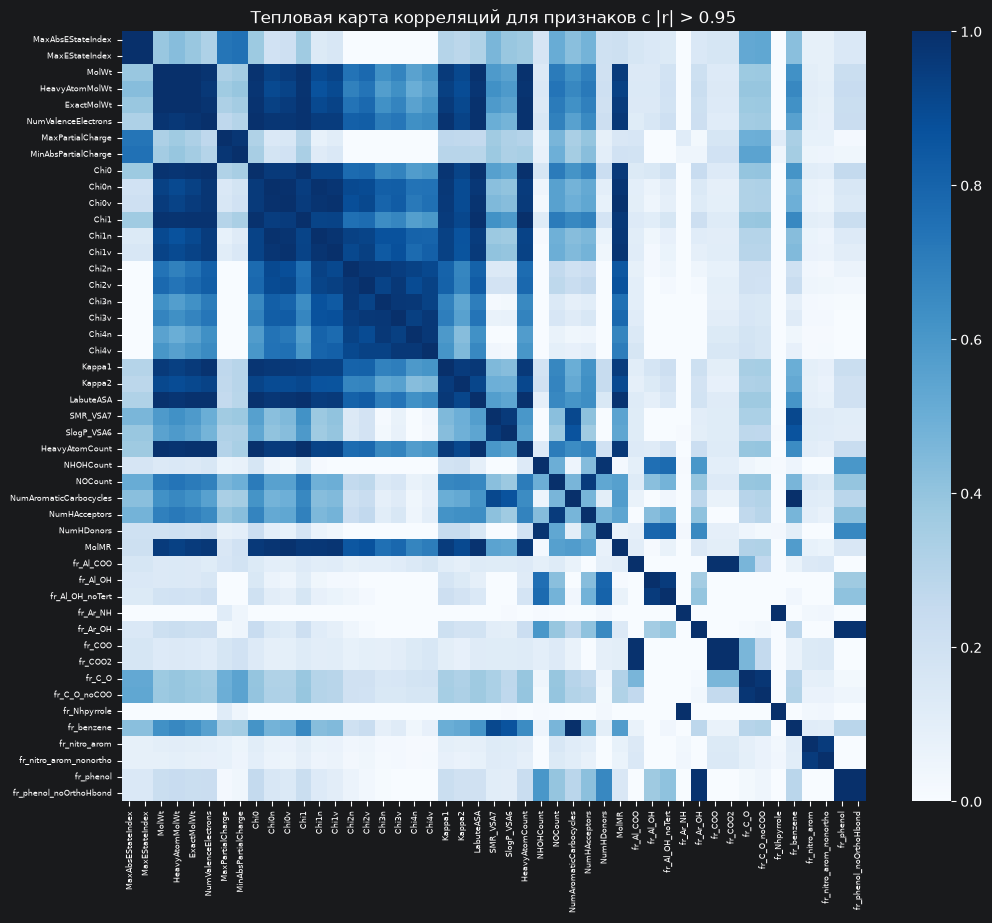

In [11]:
feature_data_without_constants = feature_data.drop(columns=constant_features)
corr_matrix = feature_data_without_constants.corr()

high_corr = corr_matrix.abs() > 0.95

correlated_features = []
for feature in high_corr.columns:
    others = high_corr.loc[feature, high_corr.columns != feature]
    if others.any():
        correlated_features.append(feature)

print(f"Признаков с хотя бы одной корреляцией > 0.95: {len(correlated_features)}")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix.loc[correlated_features, correlated_features],
    cmap="Blues", vmin=0, vmax=1,
    xticklabels=True, yticklabels=True,
)
plt.title("Тепловая карта корреляций для признаков с |r| > 0.95")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.show()

На тепловой карте видно несколько тёмно-синих блоков — это группы признаков, которые сильно скоррелированы друг с другом. Для молекулярных дескрипторов это логично: разные способы описать молекулу часто дают почти одинаковые числа.

Среди признаков есть полные дубликаты: например, MaxAbsEStateIndex и MaxEStateIndex. MolWt и ExactMolWt не совпадают полностью, но имеют почти идеальную корреляцию.

## 10. Связь признаков с целевыми переменными

In [12]:
top_corr_tables = []

for target in TARGET_COLUMNS:
    correlations = (
        feature_data_without_constants
        .corrwith(data[target])
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    target_table = correlations.reset_index()
    target_table.columns = ["feature", "abs_corr"]
    target_table.insert(0, "target", target)
    top_corr_tables.append(target_table)

    display(target_table)

top_target_correlations = pd.concat(top_corr_tables, ignore_index=True)

,target,feature,abs_corr
0,"IC50, mM",VSA_EState4,0.264838
1,"IC50, mM",Chi2n,0.252477
2,"IC50, mM",PEOE_VSA7,0.249386
3,"IC50, mM",Chi2v,0.244996
4,"IC50, mM",Chi4v,0.238554
5,"IC50, mM",Chi4n,0.237804
6,"IC50, mM",Chi3n,0.233881
7,"IC50, mM",Chi3v,0.232502
8,"IC50, mM",SlogP_VSA5,0.230400
9,"IC50, mM",MolLogP,0.225549


,target,feature,abs_corr
0,"CC50, mM",MolMR,0.312279
1,"CC50, mM",LabuteASA,0.312227
2,"CC50, mM",MolWt,0.310567
3,"CC50, mM",ExactMolWt,0.310507
4,"CC50, mM",Chi0,0.309054
5,"CC50, mM",HeavyAtomCount,0.308748
6,"CC50, mM",HeavyAtomMolWt,0.307811
7,"CC50, mM",Chi1,0.307269
8,"CC50, mM",Kappa1,0.305670
9,"CC50, mM",NumValenceElectrons,0.304513


,target,feature,abs_corr
0,SI,fr_NH2,0.170375
1,SI,BalabanJ,0.168786
2,SI,RingCount,0.127824
3,SI,fr_Al_COO,0.104186
4,SI,fr_COO2,0.102801
5,SI,fr_COO,0.102801
6,SI,VSA_EState4,0.091061
7,SI,NumAromaticRings,0.090447
8,SI,FpDensityMorgan1,0.087432
9,SI,VSA_EState6,0.085104


## 11. Итоговые выводы по EDA

Данные: 969 строк, 213 колонок после удаления технического индекса и 32 дубликатов. Все колонки числовые.

- Повторяющиеся наборы признаков: 969 строк соответствуют 804 уникальным комбинациям дескрипторов. В моделировании сравним полный набор и набор без повторяющихся комбинаций
- Пропуски: 36 значений в 12 признаках, не более 3 на колонку. Заполним медианой
- Целевые переменные: сильная асимметрия у всех трёх, максимум — у SI (среднее 74 при медиане 3.9). Для регрессии используем log1p
- Выбросы: IC50 — 138 (14%), SI — 120 (12%), CC50 — 35 (4%). Удаление улучшает метрики, но это упрощение задачи, а не улучшение модели — теряем самые перспективные молекулы. Не удаляем, используем log1p и MAE
- Баланс классов: разбиение по медиане даёт 50/50. SI > 8 — дисбаланс 64/36, для этой задачи добавляем F1 и ROC-AUC
- Константные признаки: обнаружено 18 константных и ещё 34 почти константных признака. Почти константные пока оставляем
- Корреляции: на тепловой карте видны группы сильно скоррелированных признаков, в том числе полные дубликаты. Для линейных моделей нужна регуляризация или отбор признаков